# 02 · Exploratory Data Analysis

Real transaction data, ~1,000 cards, ~700 merchants, Jan 2019 - Dec 2020. Unlike a
synthetic dataset, we don't know the fraud "patterns" in advance — this notebook's job is
to actually discover what fraud looks like here before we engineer features around it.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

txns = pd.read_parquet("../data/raw/transactions.parquet")
users = pd.read_parquet("../data/raw/users.parquet")
merchants = pd.read_parquet("../data/raw/merchants.parquet")

txns["timestamp"] = pd.to_datetime(txns["timestamp"])
txns["hour"] = txns.timestamp.dt.hour
txns["dow"] = txns.timestamp.dt.day_name()
txns["date"] = txns.timestamp.dt.date
txns["month"] = txns.timestamp.dt.to_period("M")

txns.shape, users.shape, merchants.shape

((1048575, 17), (943, 11), (693, 6))

In [2]:
print(f"Transactions: {len(txns):,}")
print(f"Date range:   {txns.timestamp.min()} -> {txns.timestamp.max()}")
print(f"Unique cards: {txns.user_id.nunique():,}")
print(f"Unique merchants: {txns.merchant_id.nunique():,}")
print(f"Fraud rate:   {txns.is_fraud.mean():.4%}  ({txns.is_fraud.sum():,} fraud txns)")
txns[["amount"]].describe()

Transactions: 1,048,575
Date range:   2019-01-01 00:00:00 -> 2020-03-10 16:08:00
Unique cards: 943
Unique merchants: 693
Fraud rate:   0.5728%  (6,006 fraud txns)


,amount
count,1.048575e+06
mean,7.027910e+01
std,1.599518e+02
min,1.000000e+00
25%,9.640000e+00
50%,4.745000e+01
75%,8.305000e+01
max,2.894890e+04


## Class imbalance and volume over time

Worth watching how volume/fraud rate move month to month — real calendar effects (holiday shopping, seasonality) are exactly the kind of thing that causes real, not simulated, distribution drift later in `06_drift_monitoring.ipynb`.

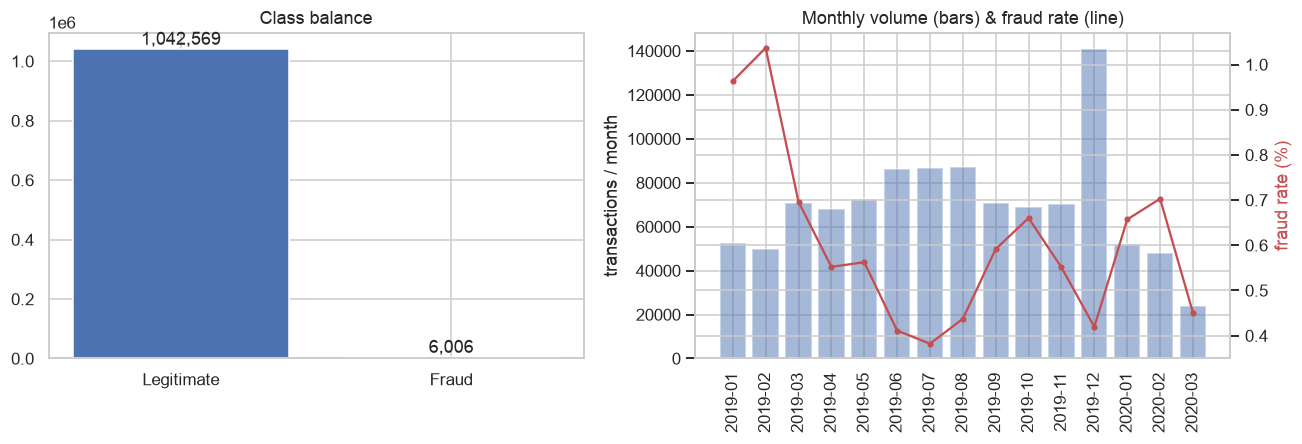

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = txns.is_fraud.value_counts().sort_index()
axes[0].bar(["Legitimate", "Fraud"], counts.values, color=["#4C72B0", "#C44E52"])
axes[0].set_title("Class balance")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

monthly = txns.groupby("month").agg(volume=("is_fraud", "size"), fraud_rate=("is_fraud", "mean"))
ax2 = axes[1]
ax2.bar(monthly.index.astype(str), monthly.volume, color="#4C72B0", alpha=0.5, label="volume")
ax2.set_ylabel("transactions / month")
ax2.tick_params(axis="x", rotation=90)
ax2b = ax2.twinx()
ax2b.plot(monthly.index.astype(str), monthly.fraud_rate * 100, color="#C44E52", marker="o", markersize=3)
ax2b.set_ylabel("fraud rate (%)", color="#C44E52")
ax2.set_title("Monthly volume (bars) & fraud rate (line)")
plt.tight_layout()
plt.show()

## Amount distributions

How does the fraud amount distribution compare to legitimate spend?

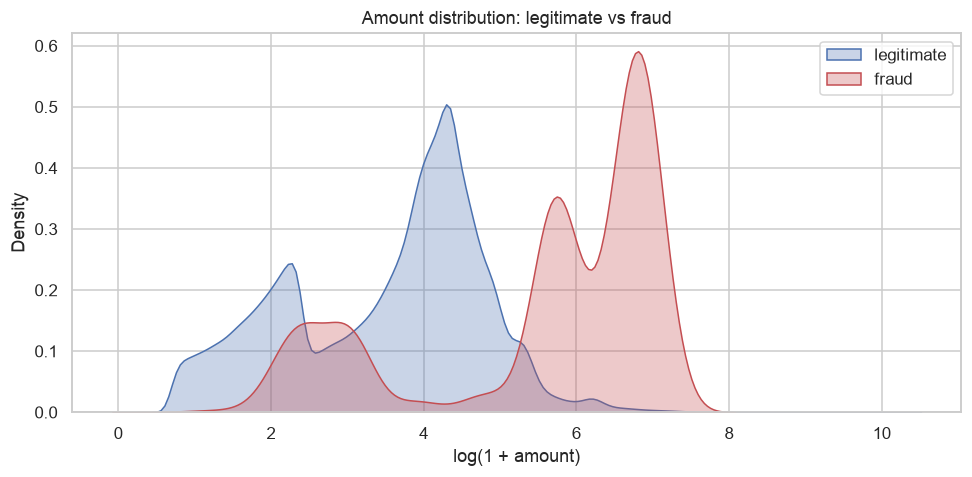

,count,mean,50%,std,max
is_fraud,,,,,
0,1042569.0,67.627445,47.220,153.695606,28948.90
1,6006.0,530.573492,391.165,391.333069,1371.81


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, mask, color in [
    ("legitimate", txns.is_fraud == 0, "#4C72B0"),
    ("fraud", txns.is_fraud == 1, "#C44E52"),
]:
    sns.kdeplot(np.log1p(txns.loc[mask, "amount"]), label=label, fill=True, alpha=0.3, ax=ax, color=color)
ax.set_xlabel("log(1 + amount)")
ax.set_title("Amount distribution: legitimate vs fraud")
ax.legend()
plt.tight_layout()
plt.show()

txns.groupby("is_fraud")["amount"].describe()[["count", "mean", "50%", "std", "max"]]

## Temporal patterns: hour of day, day of week

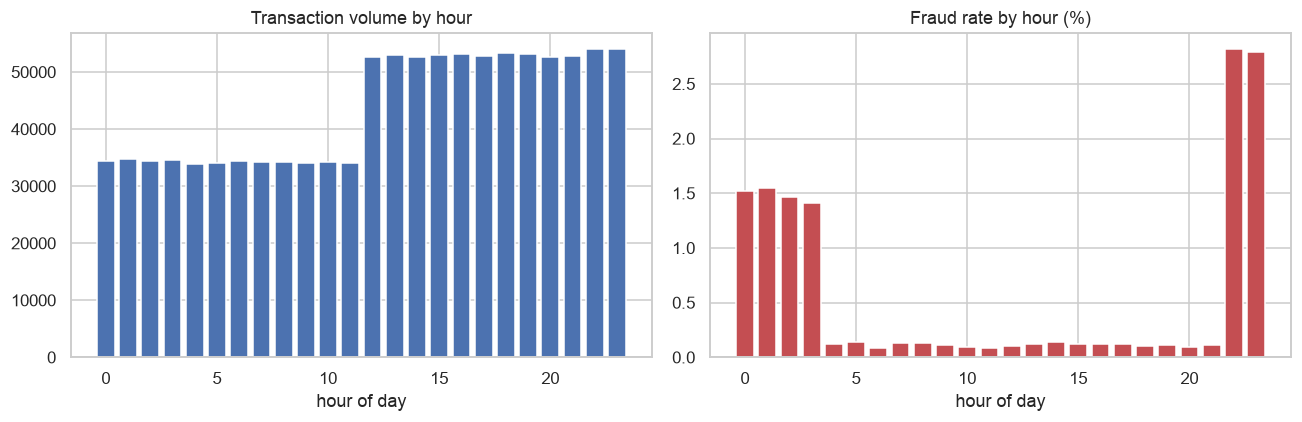

In [5]:
fraud_by_hour = txns[txns.is_fraud == 1].groupby("hour").size()
all_by_hour = txns.groupby("hour").size()
rate_by_hour = (fraud_by_hour / all_by_hour * 100).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(all_by_hour.index, all_by_hour.values, color="#4C72B0")
axes[0].set_title("Transaction volume by hour")
axes[0].set_xlabel("hour of day")

axes[1].bar(rate_by_hour.index, rate_by_hour.values, color="#C44E52")
axes[1].set_title("Fraud rate by hour (%)")
axes[1].set_xlabel("hour of day")
plt.tight_layout()
plt.show()

## Merchant category risk

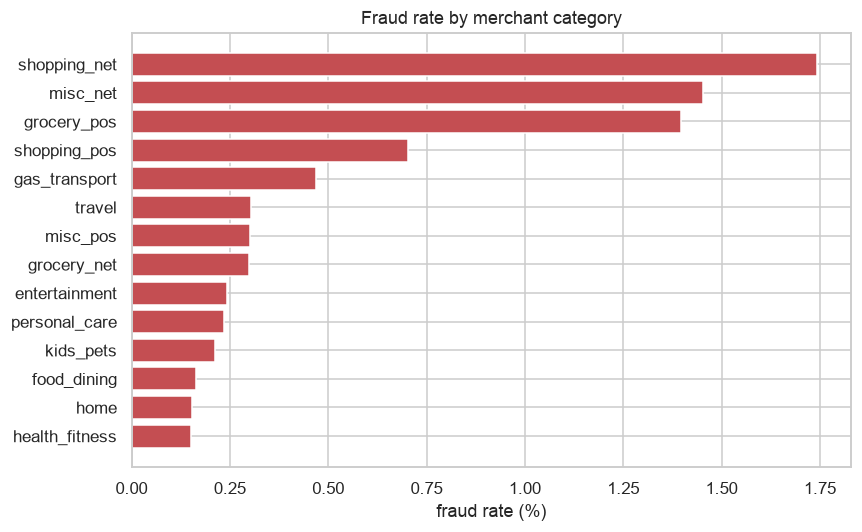

,txns,fraud_rate
category,,
shopping_net,78899,0.017427
misc_net,51082,0.014526
grocery_pos,99906,0.013973
shopping_pos,94353,0.007016
gas_transport,106430,0.004679
travel,32830,0.003046
misc_pos,64492,0.003008
grocery_net,36719,0.002996
entertainment,75981,0.002435


In [6]:
cat_stats = txns.groupby("category").agg(
    txns=("is_fraud", "size"), fraud_rate=("is_fraud", "mean")
).sort_values("fraud_rate", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(cat_stats.index[::-1], cat_stats.fraud_rate.values[::-1] * 100, color="#C44E52")
ax.set_xlabel("fraud rate (%)")
ax.set_title("Fraud rate by merchant category")
plt.tight_layout()
plt.show()

cat_stats

## Distance from home

Since merchant location is simulated per-transaction near (or, for some fraud cases, deliberately far from) the cardholder's registered address, distance-from-home is a strong candidate signal — let's check.

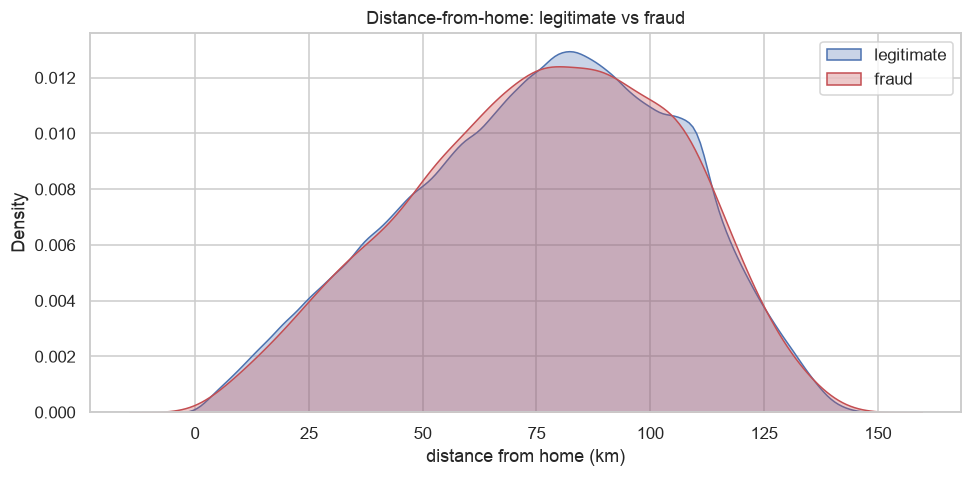

,count,mean,50%,max
is_fraud,,,,
0,1042569.0,76.101398,78.212461,152.117173
1,6006.0,76.237524,77.869499,144.522410


In [7]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

txns["distance_from_home_km"] = haversine_km(
    txns.home_lat, txns.home_lon, txns.merchant_lat, txns.merchant_lon
)

fig, ax = plt.subplots(figsize=(9, 4.5))
for label, mask, color in [
    ("legitimate", txns.is_fraud == 0, "#4C72B0"),
    ("fraud", txns.is_fraud == 1, "#C44E52"),
]:
    sns.kdeplot(txns.loc[mask, "distance_from_home_km"], label=label, fill=True, alpha=0.3, ax=ax, color=color)
ax.set_xlabel("distance from home (km)")
ax.set_title("Distance-from-home: legitimate vs fraud")
ax.legend()
plt.tight_layout()
plt.show()

txns.groupby("is_fraud")["distance_from_home_km"].describe()[["count", "mean", "50%", "max"]]

## Demographic fields: descriptive only

We check whether `gender` / age correlate with fraud purely out of EDA curiosity — **not**
because either will become a model feature (see the responsible-AI note in notebook 01).

In [8]:
gender_map = users.set_index("user_id")["gender"]
txns["gender"] = txns.user_id.map(gender_map)
print(txns.groupby("gender").is_fraud.agg(["size", "mean"]))

dob_map = users.set_index("user_id")["dob"]
txns["age_years"] = (txns.timestamp - txns.user_id.map(dob_map)).dt.days / 365.25
age_bins = pd.cut(txns.age_years, bins=[0, 25, 35, 45, 55, 65, 100])
print("\n", txns.groupby(age_bins, observed=True).is_fraud.agg(["size", "mean"]))

          size      mean
gender                  
F       574367  0.005201
M       474208  0.006366

              size      mean
age_years                  
(0, 25]     98573  0.006696
(25, 35]   232746  0.004559
(35, 45]   181914  0.004183


## Takeaways for feature engineering

- Severe class imbalance (~fraud rate reported above) → PR-AUC / cost-based threshold, not
  accuracy or a default 0.5 cutoff.
- **Distance from home** is a genuinely strong, real geo signal in this dataset (unlike a
  fabricated "impossible travel" feature, which we're intentionally not building — see
  notebook 01's geography sanity check for why).
- **Merchant category** carries real, stable risk differences — worth a causal, leakage-safe
  rolling fraud-rate encoding rather than a static one-hot.
- Amount alone is a weak signal (large overlap between the two distributions) — this will
  need to combine with velocity and merchant/category risk, not stand alone.
- Demographic fields (`gender`, `age`, `job`, `city_pop`) are explicitly **excluded** from
  the model's feature set for fair-lending-style governance reasons, even where a raw
  correlation with the label exists.

Next: `03_feature_engineering.ipynb` builds a leakage-safe feature table from these signals.